In [9]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl
import itertools


from scipy.linalg import expm, solve
from scipy.spatial import ConvexHull
from scipy.stats import pearsonr
from numpy.linalg import matrix_rank
from itertools import combinations, product

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.cm as cm

## Part 1

In [ ]:
def solve_kepler(M, e, tol=1e-8):
    """Newton-Raphson solver for Kepler's Equation: M = E - e*sin(E)"""
    E = M
    for _ in range(100):
        dE = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
        E -= dE
        if abs(dE) < tol:
            break
    return E

In [ ]:
def generate_augmented_trajectory_ya(x0, U_set, N=100, tf=200.0, e=0.1, a=7102.8e3):
    """
    Generate spacecraft rendezvous trajectory using Yamanaka-Ankersen (YA) model.
    Uses piecewise Zero-Order Hold (ZOH) discretization.
    """

    Delta_t = tf / N

    # Orbital parameters (Chief)
    mu = 3.986e14
    n_mean = np.sqrt(mu / a**3)      # Mean motion
    h = np.sqrt(mu * a * (1 - e**2)) # Specific angular momentum
    p = a * (1 - e**2)               # Semi-latus rectum

    # Precompute time-varying discretized matrices
    A_d_list = []
    B_d_list = []

    for k in range(N):
        t_k = k * Delta_t
        M_k = n_mean * t_k  # Assuming mean anomaly is 0 at t=0
        
        # Map time to true anomaly
        E_k = solve_kepler(M_k, e)
        # Robust true anomaly calculation avoiding quadrant issues
        f_k = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E_k / 2), 
                             np.sqrt(1 - e) * np.cos(E_k / 2))
        
        # Instantaneous orbit properties
        r_k = p / (1 + e * np.cos(f_k))
        f_dot = h / r_k**2
        r_dot = (mu / h) * e * np.sin(f_k)
        f_ddot = -2 * (r_dot / r_k) * f_dot

        # YA Continuous A matrix evaluated at t_k
        A_k = np.zeros((6, 6))
        A_k[0:3, 3:6] = np.eye(3)
        A_k[3, 0] = f_dot**2 + 2 * mu / r_k**3
        A_k[3, 1] = f_ddot
        A_k[3, 4] = 2 * f_dot
        A_k[4, 0] = -f_ddot
        A_k[4, 1] = f_dot**2 - mu / r_k**3
        A_k[4, 3] = -2 * f_dot
        A_k[5, 2] = -mu / r_k**3

        # Continuous B matrix (constant in LVLH)
        B_k = np.zeros((6, 3))
        B_k[3:, :] = np.eye(3)

        # ZOH discretization for this specific interval
        M_mat = np.zeros((9, 9))
        M_mat[:6, :6] = A_k
        M_mat[:6, 6:] = B_k
        Md = expm(M_mat * Delta_t)
        
        A_d_list.append(Md[:6, :6])
        B_d_list.append(Md[:6, 6:])

    # Compute the Convex Hull
    hull = ConvexHull(U_set)

    # Extract the H-representation (Ax <= b)
    A_u = hull.equations[:, :-1]
    b_u = -hull.equations[:, -1]

    # Tight L1 bound
    norms = np.sum(np.abs(U_set), axis=1)
    u_bar = np.max(norms)
    u_ubar = np.min(norms)

    # Decision variables
    x = cp.Variable((6, N+1))
    x_c = cp.Variable((1, N+1))
    u = cp.Variable((3, N))
    nu = cp.Variable((1, N))

    constraints = [x[:,0] == x0, x_c[:,0] == 0]

    for k in range(N):
        constraints += [
            x[:,k+1] == A_d_list[k] @ x[:,k] + B_d_list[k] @ u[:,k],
            x_c[:,k+1] == x_c[:,k] + Delta_t * nu[:,k],
            nu[:,k] >= u_ubar,
            nu[:,k] >= cp.norm1(u[:,k]),
            nu[:,k] <= u_bar,
            A_u @ u[:,k] <= b_u
        ]

    xf = np.zeros(6)
    constraints += [x[:,N] == xf]

    objective = cp.Minimize(x_c[:,N])
    prob = cp.Problem(objective, constraints)

    # Solve without verbose output
    prob.solve(solver=cp.ECOS, verbose=False)

    x_traj = x.value
    x_c_traj = x_c.value
    u_traj = u.value
    nu_traj = nu.value
    solver_time = prob.solver_stats.solve_time  # Solver time in seconds

    return x_traj, x_c_traj, u_traj, nu_traj, prob.value, solver_time

In [ ]:
def plot_cp_trajectory_results(cp_results, U_set, tf=200.0, u_max=5/100, save_plots=False, show_title=False):

    # Font settings
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.rm": "Times New Roman",
        'text.usetex': True,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7
    })

    # Unpack
    x_cp, u_cp, _ = cp_results
    N_cp = x_cp.shape[1] - 1
    time_cp = np.linspace(0, tf, N_cp + 1)

    # -----------------------
    # Compute average distance for single trajectory
    # -----------------------
    u_traj_array = np.array(u_cp).T  # shape (N,3) if u_cp was (3,N)
    dists = []
    normalized_dists = []
    for u_t in u_traj_array:
        diffs = u_t[None, :] - U_set  # (P,3)
        dist = np.linalg.norm(diffs, axis=1)   # (P,)
        dists.append(np.min(dist))             # closest discrete point
        normalized_dists.append((np.min(dist))/u_max)
    avg_distance = np.mean(dists)
    avg_norm_distance = np.mean(normalized_dists)
    print(f"Average distance to discrete set: {avg_distance:.6f}")
    print(f"Normalized Average distance to discrete set: {avg_norm_distance:.6f}")

    # ---------------------------------------------------------
    # Plot 1: 2D Trajectory in Hill Frame (In-Plane)
    # ---------------------------------------------------------
    plt.figure(figsize=(3.5, (3.5/4)*2))

    # Along-track (y) vs Radial (x)
    plt.plot(x_cp[1, :], x_cp[0, :], linewidth=1.5, color='C0')

    # ---------------------------------------------------------
    # Markers for Start and Chief
    # ---------------------------------------------------------
    plt.scatter(x_cp[1, 0], x_cp[0, 0],
                color='forestgreen', marker='o', s=30,
                label='$r(0)$', zorder=5)

    plt.scatter(0, 0,
                color='red', marker='x', s=40,
                label='Chief', zorder=5)

    plt.xlabel('$y$ (Along-track) [m]')
    plt.ylabel('$x$ (Radial) [m]')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()

    if save_plots:
        plt.savefig("ya_trajectory_2d.pdf")

    plt.show()

    # ------------------------
    # Plot: Spacecraft States (2 subplots)
    # ------------------------
    fig, axs = plt.subplots(2, 1, figsize=(3.5, (3.5/4)*2.5), sharex=True)

    pos_symbols = ['r_x', 'r_y', 'r_z']
    vel_symbols = ['v_x', 'v_y', 'v_z']

    pos_units = r'[\mathrm{m}]'
    vel_units = r'[\mathrm{m}/\mathrm{s}]'

    # ------------------------
    # Position subplot
    # ------------------------
    for i in range(3):
        axs[0].plot(time_cp, x_cp[i, :], linewidth=1.5, label=f'${pos_symbols[i]}$', color=f'C{i}')

    axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)
    axs[0].set_ylabel(r'$r\;[\mathrm{m}]$', fontsize=9)
    axs[0].grid(True)
    axs[0].set_xlim([0, tf])
    axs[0].legend(fontsize=8)

    if show_title:
        axs[0].set_title('Spacecraft States')

    # ------------------------
    # Velocity subplot
    # ------------------------
    for i in range(3):
        axs[1].plot(time_cp, x_cp[i+3, :], linewidth=1.5, label=f'${vel_symbols[i]}$', color=f'C{i}')

    axs[1].axhline(0, color='k', linestyle='--', linewidth=0.8)
    axs[1].set_ylabel(r'$v\;[\mathrm{m/s}]$', fontsize=9)
    axs[1].grid(True)
    axs[1].set_xlim([0, tf])
    axs[1].legend(fontsize=8, loc='upper left')

    axs[1].set_xlabel('Time [s]', fontsize=9)

    plt.subplots_adjust(hspace=0.25)
    plt.tight_layout(pad=1.0)

    if save_plots:
        plt.savefig("spacecraft_states_cp.pdf", bbox_inches='tight')

    plt.show()

    # ------------------------
    # Plot 2: Control Inputs (3 subplots)
    # ------------------------
    fig, axes = plt.subplots(3, 1, figsize=(3.5, (3.5/4)*3), sharex=True)
    ctrl_symbols = ['u_x', 'u_y', 'u_z']
    ctrl_units   = r'[\mathrm{m}/\mathrm{s}^2]'

    for i, ax in enumerate(axes):
        ax.step(time_cp[:-1], u_cp[i, :], where='post', linewidth=1.5, color=f'C{i}')
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(u_max, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(-u_max, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

        label = '$' + ctrl_symbols[i] + r'\;' + ctrl_units + '$'
        ax.set_ylabel(label, fontsize=9)
        ax.grid(True)

    axes[-1].set_xlabel('Time [s]', fontsize=9)
    for ax in axes:
        ax.set_xlim([0, tf])

    plt.subplots_adjust(hspace=0.25)
    plt.tight_layout(pad=1.0)
    if save_plots:
        plt.savefig("control_inputs_cp.pdf", bbox_inches='tight')
    plt.show()

    return None


/opt/miniconda3/envs/cvxpy_env/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


Convexified Augmened (CP) trajectory cost: 13.4005
Convexified Augmened (CP) Solving time: 0.1696
Average distance to discrete set: 0.000107
Normalized Average distance to discrete set: 0.002136


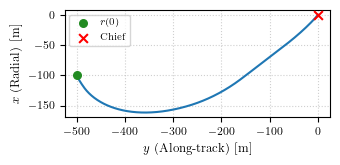

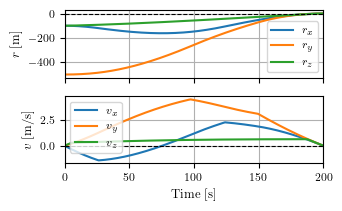

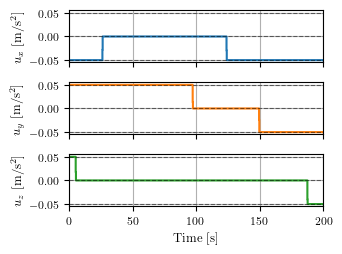

In [5]:
m_mass = 100.0  # [kg]
F_thrust = 5.0  # [N]
u_max = F_thrust / m_mass  # 0.05

# Number of actuators
m_dim = 3

# 1. Generate the discrete input set U_set
u_values = [-u_max, 0.0, u_max]
U_set = np.array(list(itertools.product(u_values, repeat=m_dim)))

x0 = np.array([-100.0, -500.0, -100.0, 0, 0, 0])
t_f = 200.0
eccentricity = 0.7
semi_major_axis = 7102.8e3 

# Convexified solution
aug_cp_results = generate_augmented_trajectory_ya(x0, U_set, N=1000, tf=t_f, e=eccentricity, a=semi_major_axis)
x_aug, x_c_aug, u_aug, nu_aug, cost_aug, solv_time = aug_cp_results
cp_results = x_aug, u_aug, cost_aug

print(f"Convexified Augmened (CP) trajectory cost: {cost_aug:.4f}")
print(f"Convexified Augmened (CP) Solving time: {solv_time:.4f}")

plot_cp_trajectory_results(cp_results, U_set, tf=t_f, save_plots=True)


## Part 2

In [ ]:
def grid_size_test_feasible_set(num_IC=10, x0_bounds=None, N_0=100, N_f=1000, N_step=10, tf=200.0, max_attempts=5000):
    """
    Perform a grid size test using a set of feasible initial conditions.
    """

    m_mass = 100.0  # [kg]
    F_thrust = 5.0  # [N]
    u_max = F_thrust / m_mass  # 0.05

    # Number of actuators
    m_dim = 3

    # Generate the discrete input set U_set
    u_values = [-u_max, 0.0, u_max]
    U_set = np.array(list(itertools.product(u_values, repeat=m_dim)))

    eccentricity = 0.7
    semi_major_axis = 7102.8e3 

    if x0_bounds is None:
        x0_bounds = {
            'pos': [-500.0, 500.0],
            'vel': [-5.0, 5.0]
        }

    # -----------------------
    # Generate feasible ICs
    # -----------------------
    ICs = []
    attempts = 0
    while len(ICs) < num_IC and attempts < max_attempts:
        attempts += 1
        x0_candidate = np.zeros(6)
        x0_candidate[:3] = np.random.uniform(x0_bounds['pos'][0], x0_bounds['pos'][1], 3)
        x0_candidate[3:] = np.random.uniform(x0_bounds['vel'][0], x0_bounds['vel'][1], 3)

        try:
            # Try generating trajectory with initial grid size
            aug_cp_results = generate_augmented_trajectory_ya(x0_candidate, U_set, N=N_0, tf=t_f, e=eccentricity, a=semi_major_axis)
            ICs.append(x0_candidate)
            print(f"Feasible IC {len(ICs)} found after {attempts} attempts")
        except Exception:
            continue

    if len(ICs) < num_IC:
        raise RuntimeError("Could not find enough feasible initial conditions.")

    # -----------------------
    # Grid size test
    # -----------------------
    N_list = list(range(N_0, N_f + 1, N_step))
    solver_times = np.zeros((num_IC, len(N_list)))
    u_all = [[None for _ in N_list] for _ in range(num_IC)]

    for ic_idx, x0 in enumerate(ICs):
        print(f"\nTesting IC {ic_idx+1}/{num_IC}")
        for n_idx, N in enumerate(N_list):
            try:
                aug_cp_results = generate_augmented_trajectory_ya(x0, U_set, N=N, tf=t_f, e=eccentricity, a=semi_major_axis)
                x_aug, x_c_aug, u_aug, nu_aug, cost_aug, solve_time = aug_cp_results
                solver_times[ic_idx, n_idx] = solve_time
                u_all[ic_idx][n_idx] = u_aug
            except Exception as e:
                print(f"N={N} failed for IC {ic_idx+1}: {e}")
                solver_times[ic_idx, n_idx] = np.nan
                u_all[ic_idx][n_idx] = None

    results = {
        'N_list': N_list,
        'solver_times': solver_times,
        'u_all': u_all,
        'ICs': np.array(ICs)
    }

    return results


In [ ]:
def plot_grid_size_tradeoff_mean(results, u_max=5/100, save_plots=False):
    """
    Plot solver time vs grid size and averaged distance to discrete set vs grid size using multiple ICs.
    """

    # -----------------------
    # Font settings (applied locally here)
    # -----------------------
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.rm": "Times New Roman",
        'text.usetex': True,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7
    })

    N_list = np.array(results['N_list'])
    solver_times = np.array(results['solver_times'])
    u_all = results['u_all']
    num_IC = solver_times.shape[0]

    # Generate the discrete input set U_set
    u_values = [-u_max, 0.0, u_max]
    U_set = np.array(list(itertools.product(u_values, repeat=m_dim)))

    # -----------------------
    # Compute averaged distance
    # -----------------------
    averaged_distances = np.zeros_like(solver_times, dtype=float)
    averaged_norm_distances = np.zeros_like(solver_times, dtype=float)

    for ic_idx in range(num_IC):
        for n_idx, u_traj in enumerate(u_all[ic_idx]):
            if u_traj is None:
                averaged_distances[ic_idx, n_idx] = np.nan
                averaged_norm_distances[ic_idx, n_idx] = np.nan
                continue

            u_traj_array = np.array(u_traj)
            if u_traj_array.ndim == 2:
                u_traj_array = u_traj_array[None, :, :]  # add trial dimension

            T, _, N = u_traj_array.shape
            dist = np.zeros((T, N))
            for t_idx in range(N):
                u_t = u_traj_array[:, :, t_idx]
                diffs = u_t[:, None, :] - U_set
                dists = np.linalg.norm(diffs, axis=2)
                dist[:, t_idx] = np.min(dists, axis=1)

            averaged_distances[ic_idx, n_idx] = dist.mean()
            averaged_norm_distances[ic_idx, n_idx] = dist.mean() / u_max
    
    # -----------------------
    # Compute mean and std
    # -----------------------
    solver_mean = np.nanmean(solver_times, axis=0)
    solver_median = np.nanmedian(solver_times, axis=0)
    solver_std = np.nanstd(solver_times, axis=0)

    distance_mean = np.nanmean(averaged_distances, axis=0)          
    distance_median = np.nanmedian(averaged_distances, axis=0)      
    distance_std = np.nanstd(averaged_distances, axis=0)            
    p10 = np.nanpercentile(averaged_distances, 10, axis=0)          
    p90 = np.nanpercentile(averaged_distances, 90, axis=0)          

    norm_distance_mean = np.nanmean(averaged_norm_distances, axis=0)
    norm_distance_median = np.nanmedian(averaged_norm_distances, axis=0)
    norm_distance_std = np.nanstd(averaged_norm_distances, axis=0)
    norm_p10 = np.nanpercentile(averaged_norm_distances, 10, axis=0)
    norm_p90 = np.nanpercentile(averaged_norm_distances, 90, axis=0)


    # -----------------------
    # Plot mean
    # -----------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.5, 2.8), sharex=True)

    # Solver time
    ax1.plot(N_list, solver_mean, color='blue', marker='o', label='Mean')
    # ax1.fill_between(N_list, solver_mean - solver_std, solver_mean + solver_std,
    #                 color='lightblue', alpha=0.6, label='±1 std')
    ax1.set_ylabel('Solver time [s]')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()
    ax1.set_xlim(min(N_list), max(N_list))

    # Averaged distance
    ax2.plot(N_list, norm_distance_mean, color='darkred', marker='o', label='Mean')
    # scale = 1
    # ax2.fill_between(N_list, distance_mean - scale*distance_std,
    #                 distance_mean + scale*distance_std,
    #                 color='lightcoral', alpha=0.6, label='Variability')
    ax2.set_xlabel('Grid size [N]')
    ax2.set_ylabel(r'$\bar{d}(u)$')
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc="upper right")
    ax2.set_xlim(min(N_list), max(N_list))

    fig.tight_layout()

    if save_plots:
        plt.savefig("grid_size_tradeoff_mean.pdf", bbox_inches='tight')
    plt.show()


Feasible IC 1 found after 1 attempts
Feasible IC 2 found after 2 attempts
Feasible IC 3 found after 3 attempts
Feasible IC 4 found after 4 attempts
Feasible IC 5 found after 5 attempts
Feasible IC 6 found after 6 attempts
Feasible IC 7 found after 7 attempts
Feasible IC 8 found after 8 attempts
Feasible IC 9 found after 9 attempts
Feasible IC 10 found after 10 attempts

Testing IC 1/10

Testing IC 2/10

Testing IC 3/10

Testing IC 4/10

Testing IC 5/10

Testing IC 6/10

Testing IC 7/10

Testing IC 8/10

Testing IC 9/10

Testing IC 10/10


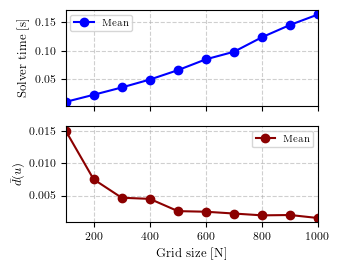

In [13]:
x0_bounds = {
    'pos': [-500.0, 500.0],
    'vel': [-5.0, 5.0]
}
t_f = 200.0

num_ICs = 10  # number of initial conditions to test

results = grid_size_test_feasible_set(
    num_IC=num_ICs,
    x0_bounds=x0_bounds,
    N_0=100,
    N_f=1000,
    N_step=100,
    tf=t_f
)

plot_grid_size_tradeoff_mean(
    results,
    u_max=5/100,
    save_plots=True
)


## Part 3

In [ ]:
def monte_carlo_cp(num_samples=100, N=300, tf=200.0, bounds=None, adjust_tf=False, tf_increment=50.0, max_tf=1000.0):
    """
    Perform Monte Carlo simulations for the convexified trajectory optimization.
    """

    m_mass = 100.0  # [kg]
    F_thrust = 5.0  # [N]
    u_max = F_thrust / m_mass  # 0.05

    # Number of actuators
    m_dim = 3

    # Generate the discrete input set U_set
    u_values = [-u_max, 0.0, u_max]
    U_set = np.array(list(itertools.product(u_values, repeat=m_dim)))

    eccentricity = 0.3
    semi_major_axis = 7102.8e3 

    if bounds is None:
        bounds = {
            'pos': [-500.0, 500.0],  # x, y, z positions
            'vel': [-5.0, 5.0]       # vx, vy, vz velocities
        }

    costs = []
    solver_times = []
    u_all = []

    trial = 0
    attempted = 0  # Count all attempted initial conditions

    while trial < num_samples:
        attempted += 1

        # Sample initial conditions uniformly within bounds
        x0 = np.zeros(6)
        x0[:3] = np.random.uniform(bounds['pos'][0], bounds['pos'][1], 3)
        x0[3:] = np.random.uniform(bounds['vel'][0], bounds['vel'][1], 3)

        current_tf = tf
        feasible = False

        while not feasible:
            try:
                # Call updated function that returns solver time
                aug_cp_results = generate_augmented_trajectory_ya(x0, U_set, N=N, tf=current_tf, e=eccentricity, a=semi_major_axis)
                x_aug, x_c_aug, u_aug, nu_aug, cost_aug, solve_time = aug_cp_results
                feasible = (cost_aug is not None) and np.isfinite(cost_aug)
                # feasible = (cost_aug is not None)
            except Exception:
                feasible = False
                if adjust_tf:
                    current_tf += tf_increment
                    if current_tf > max_tf:
                        print(f"Initial condition infeasible, skipping attempt {attempted}.")
                        break
                else:
                    # Skip this initial condition and resample
                    break

        if feasible:
            costs.append(cost_aug)
            solver_times.append(solve_time)
            u_all.append(u_aug)
            trial += 1
            print(f'Trial {trial}/{num_samples} | Attempted: {attempted} | Feasible: {trial} | '
                  f'Terminal cost: {cost_aug:.4f} | Solver time: {solve_time:.4f} s | tf={current_tf:.1f}')

    return solver_times, u_all

In [ ]:
def discreteness_report(u_all, solver_times, u_max=5/100, eps_discrete=0.05, save_plots=False):
    
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.rm": "Times New Roman",
        'text.usetex': True,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7
    })

    u_array = np.array(u_all)            # (T, 3, N)
    solver_times = np.array(solver_times)
    T, _, N = u_array.shape

    # Generate the discrete input set U_set
    u_values = [-u_max, 0.0, u_max]
    U_set = np.array(list(itertools.product(u_values, repeat=3)))

    u_array = np.array(u_all)            # (T, 3, N)
    solver_times = np.array(solver_times)
    T, _, N = u_array.shape

    # -----------------------
    # Distances per time step

    dist = np.zeros((T, N))
    for t in range(N):
        u_t = u_array[:, :, t]                               # (T, 3)
        diffs = u_t[:, None, :] - U_set[None, :, :]          # (T, P, 3)
        dists = np.linalg.norm(diffs, axis=2)                 # (T, P)
        dist[:, t] = np.min(dists, axis=1)                    # (T,)

    # -----------------------
    # Metrics based on averaged distance
    averaged_distance      = dist.mean(axis=1)               # (T,) per-trial averaged distance
    averaged_norm_distance = averaged_distance / u_max        # (T,) normalized

    mean_averaged_distance      = averaged_distance.mean()
    median_averaged_distance    = np.median(averaged_distance)
    std_averaged_distance       = averaged_distance.std()
    max_averaged_distance       = averaged_distance.max()
    p10_averaged_distance       = np.percentile(averaged_distance, 10)
    p90_averaged_distance       = np.percentile(averaged_distance, 90)

    mean_averaged_norm_distance   = averaged_norm_distance.mean()
    median_averaged_norm_distance = np.median(averaged_norm_distance)
    std_averaged_norm_distance    = averaged_norm_distance.std()
    max_averaged_norm_distance    = averaged_norm_distance.max()
    p10_averaged_norm_distance    = np.percentile(averaged_norm_distance, 10)
    p90_averaged_norm_distance    = np.percentile(averaged_norm_distance, 90)

    # -----------------------
    # Solver time stats
    # -----------------------
    stats = {
        'mean_solver_time':   solver_times.mean(),
        'std_solver_time':    solver_times.std(),
        'median_solver_time': np.median(solver_times),
        'min_solver_time':    solver_times.min(),
        'max_solver_time':    solver_times.max(),
    }

    # -----------------------
    # Print summary
    # -----------------------
    print("=== Solver-time summary ===")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

    print("\n=== Discreteness summary ===")
    print(f"eps_discrete = {eps_discrete}")
    print(f"Averaged Distance      : mean={mean_averaged_distance:.6f}, median={median_averaged_distance:.6f}, "
        f"std={std_averaged_distance:.6f}, max={max_averaged_distance:.6f}, "
        f"p10={p10_averaged_distance:.6f}, p90={p90_averaged_distance:.6f}")
    print(f"Averaged Norm Distance : mean={mean_averaged_norm_distance:.6f}, median={median_averaged_norm_distance:.6f}, "
        f"std={std_averaged_norm_distance:.6f}, max={max_averaged_norm_distance:.6f}, "
        f"p10={p10_averaged_norm_distance:.6f}, p90={p90_averaged_norm_distance:.6f}")

    # -----------------------
    # Plots
    # -----------------------

    # 1) Solver time histogram
    plt.figure(figsize=(3.5, 1.5))
    plt.hist(solver_times, bins=20, color='C1', alpha=0.7)
    plt.xlabel('Solver time [s]')
    plt.ylabel('Count')

    plt.axvline(stats['mean_solver_time'], color='k', ls='--', lw=1.2,
                label=f"Mean={stats['mean_solver_time']:.3f}s")
    plt.axvline(stats['median_solver_time'], color='k', ls=':', lw=1.2,
                label=f"Median={stats['median_solver_time']:.3f}s")

    plt.legend(fontsize=7)
    plt.grid(True)
    if save_plots: 
        plt.savefig("solver_time_hist.pdf", bbox_inches='tight')
    plt.show()

    # 2) Histogram of averaged distance
    plt.figure(figsize=(3.5, 1.5))
    plt.hist(averaged_distance, bins=20, color='C0', alpha=0.8)

    plt.axvline(mean_averaged_distance, color='k', ls='--', lw=1.2,
                label=f"Mean={mean_averaged_distance:.3f}")
    plt.axvline(median_averaged_distance, color='k', ls=':', lw=1.2,
                label=f"Median={median_averaged_distance:.3f}")

    plt.xlabel('$\\bar{d}(u)$')
    plt.ylabel('Count')
    plt.legend(fontsize=7)
    plt.grid(True)
    if save_plots: 
        plt.savefig("hist_avg_dist.pdf", bbox_inches='tight')
    plt.show()


    # -----------------------
    # Results dictionary
    # -----------------------
    results = {
        'averaged_distance': averaged_distance,
        'mean_averaged_distance': mean_averaged_distance,
        'std_averaged_distance': std_averaged_distance,
        'max_averaged_distance': max_averaged_distance,
        'solver_time_stats': stats
    }

    return results


/opt/miniconda3/envs/cvxpy_env/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


Trial 1/1000 | Attempted: 1 | Feasible: 1 | Terminal cost: 11.5168 | Solver time: 0.0653 s | tf=400.0
Trial 2/1000 | Attempted: 2 | Feasible: 2 | Terminal cost: 13.6111 | Solver time: 0.0792 s | tf=400.0
Trial 3/1000 | Attempted: 3 | Feasible: 3 | Terminal cost: 7.0603 | Solver time: 0.2667 s | tf=400.0
Trial 4/1000 | Attempted: 4 | Feasible: 4 | Terminal cost: 16.9851 | Solver time: 0.0548 s | tf=400.0
Trial 5/1000 | Attempted: 5 | Feasible: 5 | Terminal cost: 11.3294 | Solver time: 0.0540 s | tf=400.0
Trial 6/1000 | Attempted: 6 | Feasible: 6 | Terminal cost: 13.8562 | Solver time: 0.0656 s | tf=400.0
Trial 7/1000 | Attempted: 7 | Feasible: 7 | Terminal cost: 7.7359 | Solver time: 0.0782 s | tf=400.0
Trial 8/1000 | Attempted: 8 | Feasible: 8 | Terminal cost: 13.5702 | Solver time: 0.0629 s | tf=400.0
Trial 9/1000 | Attempted: 9 | Feasible: 9 | Terminal cost: 14.7714 | Solver time: 0.0792 s | tf=400.0
Trial 10/1000 | Attempted: 10 | Feasible: 10 | Terminal cost: 9.4577 | Solver time: 

/opt/miniconda3/envs/cvxpy_env/lib/python3.12/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Trial 94/1000 | Attempted: 94 | Feasible: 94 | Terminal cost: 10.6050 | Solver time: 0.3384 s | tf=400.0
Trial 95/1000 | Attempted: 95 | Feasible: 95 | Terminal cost: 11.8672 | Solver time: 0.0630 s | tf=400.0
Trial 96/1000 | Attempted: 96 | Feasible: 96 | Terminal cost: 6.4427 | Solver time: 0.0826 s | tf=400.0
Trial 97/1000 | Attempted: 97 | Feasible: 97 | Terminal cost: 7.4815 | Solver time: 0.0726 s | tf=400.0
Trial 98/1000 | Attempted: 98 | Feasible: 98 | Terminal cost: 13.1116 | Solver time: 0.0914 s | tf=400.0
Trial 99/1000 | Attempted: 99 | Feasible: 99 | Terminal cost: 6.5912 | Solver time: 0.0676 s | tf=400.0
Trial 100/1000 | Attempted: 100 | Feasible: 100 | Terminal cost: 10.3843 | Solver time: 0.0609 s | tf=400.0
Trial 101/1000 | Attempted: 101 | Feasible: 101 | Terminal cost: 9.5697 | Solver time: 0.0722 s | tf=400.0
Trial 102/1000 | Attempted: 102 | Feasible: 102 | Terminal cost: 9.9440 | Solver time: 0.0621 s | tf=400.0
Trial 103/1000 | Attempted: 103 | Feasible: 103 | T

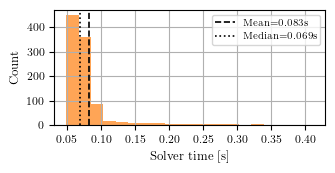

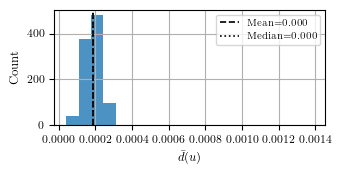

In [37]:
num_samples = 1000
solver_times, u_all = monte_carlo_cp(num_samples=num_samples, N=400, tf=400.0)

# Summary statistics
print(f"\nMonte Carlo summary ({num_samples} feasible trials):")
print(f"Mean solver time: {np.mean(solver_times):.4f} s | Std: {np.std(solver_times):.4f} s")
print(f"Min solver time: {np.min(solver_times):.4f} s | Max solver time: {np.max(solver_times):.4f} s")

results = discreteness_report(u_all, solver_times, u_max=5/100, save_plots=True)